<a href="https://colab.research.google.com/github/Jigyasa-2606/Feature-Extraction-and-Classification-of-Moving-Vehicles-on-Highways/blob/main/dark_channel_transmission.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import numpy as np
import cv2
import os
import sys
from PIL import Image
import torch
from torch.utils.data import Dataset
from torchvision import transforms
from torchvision.utils import save_image
import torch.nn as nn
from torch.utils.data import DataLoader


In [2]:
os.environ["PYTORCH_CUDA_ALLOC_CONF"] = "expandable_segments:True"

In [4]:
torch.cuda.empty_cache()

In [9]:
import cv2
import os

video_path = "/content/Highway_5_fog.mp4"
cap = cv2.VideoCapture(video_path)


total_frames = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))

train_end = int(0.7 * total_frames)
val_end = int(0.85 * total_frames)


base_path = "/content/dataset"

splits = ["train", "val", "test"]
for split in splits:
    os.makedirs(f"{base_path}/{split}/fog", exist_ok=True)

count = 0
saved = 0

while True:
    ret, frame = cap.read()
    if not ret:
        break


    if count % 5 != 0:
        count += 1
        continue


    frame = cv2.resize(frame, (256, 256))

    filename = f"frame_{saved:05d}.jpg"

    if count < train_end:
        path = f"{base_path}/train/fog/{filename}"
    elif count < val_end:
        path = f"{base_path}/val/fog/{filename}"
    else:
        path = f"{base_path}/test/fog/{filename}"

    cv2.imwrite(path, frame)

    saved += 1
    count += 1

cap.release()

print(saved, "frames extracted and split")

1126 frames extracted and split


In [10]:
import cv2
import os

video_path = "/content/Highway_5_RGB.mp4"
cap = cv2.VideoCapture(video_path)


total_frames = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))

train_end = int(0.7 * total_frames)
val_end = int(0.85 * total_frames)


base_path = "/content/dataset"

splits = ["train", "val", "test"]
for split in splits:
    os.makedirs(f"{base_path}/{split}/clear", exist_ok=True)

count = 0
saved = 0

while True:
    ret, frame = cap.read()
    if not ret:
        break


    if count % 5 != 0:
        count += 1
        continue


    frame = cv2.resize(frame, (256, 256))

    filename = f"frame_{saved:05d}.jpg"

    if count < train_end:
        path = f"{base_path}/train/clear/{filename}"
    elif count < val_end:
        path = f"{base_path}/val/clear/{filename}"
    else:
        path = f"{base_path}/test/clear/{filename}"

    cv2.imwrite(path, frame)

    saved += 1
    count += 1

cap.release()

print(saved, "frames extracted and split")

1126 frames extracted and split


In [11]:
from torch.utils.data import Dataset
import os
import cv2

class DehazeDataset(Dataset):
    def __init__(self, fog_dir, clear_dir, transform=None):
        self.fog_dir = fog_dir
        self.clear_dir = clear_dir
        self.images = sorted(os.listdir(fog_dir))
        self.transform = transform

    def __len__(self):
        return len(self.images)

    def __getitem__(self, idx):
        name = self.images[idx]

        fog = cv2.imread(os.path.join(self.fog_dir, name))
        clear = cv2.imread(os.path.join(self.clear_dir, name))

        fog = cv2.cvtColor(fog, cv2.COLOR_BGR2RGB)
        clear = cv2.cvtColor(clear, cv2.COLOR_BGR2RGB)

        if self.transform:
            fog = self.transform(fog)
            clear = self.transform(clear)

        return fog, clear

In [13]:
import os, shutil, random

base = "/content/dataset"

train_fog = f"{base}/train/fog"
train_clear = f"{base}/train/clear"

val_fog = f"{base}/val/fog"
val_clear = f"{base}/val/clear"

test_fog = f"{base}/test/fog"
test_clear = f"{base}/test/clear"

exp_base = f"{base}/experiment"

os.makedirs(f"{exp_base}/train/fog", exist_ok=True)
os.makedirs(f"{exp_base}/train/clear", exist_ok=True)

os.makedirs(f"{exp_base}/val/fog", exist_ok=True)
os.makedirs(f"{exp_base}/val/clear", exist_ok=True)

os.makedirs(f"{exp_base}/test/fog", exist_ok=True)
os.makedirs(f"{exp_base}/test/clear", exist_ok=True)

images = sorted(os.listdir(train_fog))
random.shuffle(images)

train_imgs = images[:100]
val_imgs = images[100:110]
test_imgs = images[110:112]


def copy_files(img_list, src_fog, src_clear, dst_fog, dst_clear):
  for img in img_list:
    shutil.copy(os.path.join(src_fog, img), os.path.join(dst_fog, img))
    shutil.copy(os.path.join(src_clear, img), os.path.join(dst_clear, img))

copy_files(train_imgs, train_fog, train_clear,
        f"{exp_base}/train/fog", f"{exp_base}/train/clear")

copy_files(val_imgs, train_fog, train_clear,
        f"{exp_base}/val/fog", f"{exp_base}/val/clear")

copy_files(test_imgs, train_fog, train_clear,
        f"{exp_base}/test/fog", f"{exp_base}/test/clear")

print("Experiment dataset created")

Experiment dataset created


In [23]:
import cv2
import numpy as np


def dark_channel(img, size=15):
    min_channel = np.min(img, axis=2)
    kernel = cv2.getStructuringElement(cv2.MORPH_RECT, (size, size))
    dark = cv2.erode(min_channel, kernel)
    return dark



def estimate_atmosphere(img, dark):
    h, w = img.shape[:2]
    num_pixels = int(max(h * w * 0.001, 1))

    dark_vec = dark.reshape(-1)
    img_vec = img.reshape(-1, 3)

    indices = dark_vec.argsort()[-num_pixels:]
    A = np.mean(img_vec[indices], axis=0)

    return A



def transmission(img, A, omega=0.95, size=15):
    norm_img = img / A
    dark = dark_channel(norm_img, size)
    return 1 - omega * dark


def recover(img, t, A, t0=0.1):
    t = np.clip(t, t0, 1)

    J = np.zeros_like(img)
    for c in range(3):
        J[:, :, c] = (img[:, :, c] - A[c]) / t + A[c]

    return J



def dcp_dehaze(img):
    img = img.astype('float32') / 255.0

    dark = dark_channel(img)
    A = estimate_atmosphere(img, dark)
    t = transmission(img, A)
    J = recover(img, t, A)

    return (J * 255).astype(np.uint8)


In [24]:
import os

input_dir = "/content/dataset/test/fog"
output_dir = "/content/dcp_results"

os.makedirs(output_dir, exist_ok=True)

for img_name in os.listdir(input_dir):
    img_path = os.path.join(input_dir, img_name)
    img = cv2.imread(img_path)

    result = dcp_dehaze(img)

    cv2.imwrite(os.path.join(output_dir, img_name), result)

print("DCP results generated")

DCP results generated


In [27]:
!pip install pytorch-msssim

In [28]:
import cv2
import torch
import numpy as np
from pytorch_msssim import ssim

def to_tensor(img):
    img = img.astype(np.float32) / 255.0
    return torch.from_numpy(img).permute(2,0,1).unsqueeze(0)


def psnr(pred, target):
    mse = torch.mean((pred - target) ** 2)
    return 10 * torch.log10(1.0 / mse)


def compute_ssim(pred, target):
    return ssim(pred, target, data_range=1.0)

In [29]:
import os

dcp_dir = "/content/dcp_results"
gt_dir = "/content/dataset/test/clear"

psnr_total = 0
ssim_total = 0
count = 0

files = sorted(os.listdir(gt_dir))

for name in files:
    dcp_path = os.path.join(dcp_dir, name)
    gt_path = os.path.join(gt_dir, name)


    if not os.path.exists(dcp_path):
        continue

    dcp = cv2.imread(dcp_path)
    gt = cv2.imread(gt_path)

    dcp = to_tensor(dcp)
    gt = to_tensor(gt)

    psnr_total += psnr(dcp, gt).item()
    ssim_total += compute_ssim(dcp, gt).item()

    count += 1

print("DCP Results:")
print("Avg PSNR:", psnr_total / count)
print("Avg SSIM:", ssim_total / count)

DCP Results:
Avg PSNR: 11.574420550871178
Avg SSIM: 0.7091169290288666


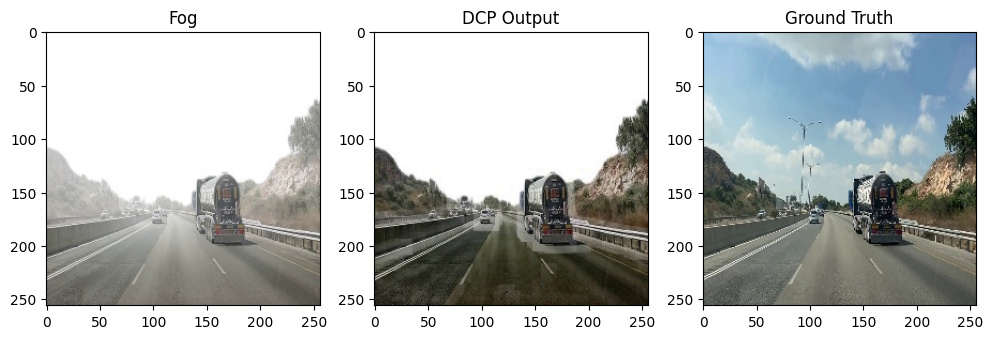

In [32]:
import matplotlib.pyplot as plt

sample = files[0]

fog = cv2.imread(f"/content/dataset/test/fog/{sample}")
dcp = cv2.imread(f"/content/dcp_results/{sample}")
gt = cv2.imread(f"/content/dataset/test/clear/{sample}")


fog = cv2.cvtColor(fog, cv2.COLOR_BGR2RGB)
dcp = cv2.cvtColor(dcp, cv2.COLOR_BGR2RGB)
gt = cv2.cvtColor(gt, cv2.COLOR_BGR2RGB)

plt.figure(figsize=(12,4))

plt.subplot(1,3,1)
plt.title("Fog")
plt.imshow(fog)

plt.subplot(1,3,2)
plt.title("DCP Output")
plt.imshow(dcp)

plt.subplot(1,3,3)
plt.title("Ground Truth")
plt.imshow(gt)

plt.show()

In [34]:
import os
import cv2

video_dir = "/content/real_dataset"
frames_dir = "/content/real_frames"

os.makedirs(frames_dir, exist_ok=True)

frame_skip = 5  # take every 5th frame

for video_name in os.listdir(video_dir):
    if not video_name.endswith(".mp4"):
        continue

    video_path = os.path.join(video_dir, video_name)
    cap = cv2.VideoCapture(video_path)

    count = 0
    saved = 0

    video_id = video_name.split(".")[0]

    while True:
        ret, frame = cap.read()
        if not ret:
            break

        if count % frame_skip != 0:
            count += 1
            continue

        frame = cv2.resize(frame, (256, 256))

        filename = f"{video_id}_frame_{saved:05d}.jpg"
        cv2.imwrite(os.path.join(frames_dir, filename), frame)

        saved += 1
        count += 1

    cap.release()
    print(f"{video_name} → {saved} frames extracted")

print("All videos processed ")

Dataset9.mp4 → 147 frames extracted
Dataset3.mp4 → 237 frames extracted
Dataset4.mp4 → 426 frames extracted
Dataset7.mp4 → 363 frames extracted
Dataset5.mp4 → 238 frames extracted
Dataset1.mp4 → 508 frames extracted
Dataset8.mp4 → 124 frames extracted
Dataset10.mp4 → 345 frames extracted
Dataset2.mp4 → 217 frames extracted
Dataset6.mp4 → 123 frames extracted
All videos processed ✅


In [35]:
dcp_out = "/content/real_dcp"
os.makedirs(dcp_out, exist_ok=True)

for img_name in os.listdir(frames_dir):
    img_path = os.path.join(frames_dir, img_name)
    img = cv2.imread(img_path)

    if img is None:
        continue

    result = dcp_dehaze(img)

    cv2.imwrite(os.path.join(dcp_out, img_name), result)

print("DCP applied to all frames ")

DCP applied to all frames 


In [37]:
output_video = "/content/dcp_video.mp4"

frame_files = sorted(os.listdir(dcp_out))
first_frame = cv2.imread(os.path.join(dcp_out, frame_files[0]))

h, w, _ = first_frame.shape
out = cv2.VideoWriter(output_video, cv2.VideoWriter_fourcc(*'mp4v'), 20, (w, h))

for f in frame_files:
    frame = cv2.imread(os.path.join(dcp_out, f))
    out.write(frame)

out.release()
print("Video saved ")

Video saved 


In [45]:
import cv2
import os
import numpy as np

def sharpness_score(folder):
    scores = []

    for img_name in os.listdir(folder):
        img = cv2.imread(os.path.join(folder, img_name))
        if img is None:
            continue

        gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
        score = cv2.Laplacian(gray, cv2.CV_64F).var()

        scores.append(score)

    return np.mean(scores)

print("DCP Sharpness:", sharpness_score("/content/real_dcp"))
print("fog Sharpness:", sharpness_score("/content/real_frames"))

DCP Sharpness: 685.787287240286
fog Sharpness: 362.6276520353094
